In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [45]:
data = pd.read_excel(r"C:\Users\jessi\Desktop\PROJECTS\supply_chain\Retail-Supply-Chain-Sales-Dataset.xlsx")

### **Data Exploration**

In [46]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Retail Sales People', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Returned', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [47]:
data.columns = (data.columns.str.replace(" ","_"))

In [48]:
data.head(2)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Retail_Sales_People,Product_ID,Category,Sub-Category,Product_Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.94,3,0.0,219.5820


In [49]:
data.set_index('Row_ID', inplace=True)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             9994 non-null   object        
 1   Order_Date           9994 non-null   datetime64[ns]
 2   Ship_Date            9994 non-null   datetime64[ns]
 3   Ship_Mode            9994 non-null   object        
 4   Customer_ID          9994 non-null   object        
 5   Customer_Name        9994 non-null   object        
 6   Segment              9994 non-null   object        
 7   Country              9994 non-null   object        
 8   City                 9994 non-null   object        
 9   State                9994 non-null   object        
 10  Postal_Code          9994 non-null   int64         
 11  Region               9994 non-null   object        
 12  Retail_Sales_People  9994 non-null   object        
 13  Product_ID           9994 non-null   o

In [51]:
# Add a month column and year column
data["Month"] = data["Order_Date"].dt.month
data["Year"] = data["Order_Date"].dt.year


In [52]:
data.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date              0
Ship_Mode              0
Customer_ID            0
Customer_Name          0
Segment                0
Country                0
City                   0
State                  0
Postal_Code            0
Region                 0
Retail_Sales_People    0
Product_ID             0
Category               0
Sub-Category           0
Product_Name           0
Returned               0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Month                  0
Year                   0
dtype: int64

In [53]:
data.nunique()

Order_ID               5009
Order_Date             1237
Ship_Date              1215
Ship_Mode                 4
Customer_ID             793
Customer_Name           793
Segment                   3
Country                   1
City                    531
State                    49
Postal_Code             631
Region                    4
Retail_Sales_People       4
Product_ID             1862
Category                  3
Sub-Category             17
Product_Name           1850
Returned                  2
Sales                  5825
Quantity                 14
Discount                 12
Profit                 7287
Month                    12
Year                      4
dtype: int64

In [54]:
data.describe()

,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit,Month,Year
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-11 07:17:44.078447104,2016-05-15 21:54:47.332399360,55190.379428,229.858001,3.789574,0.156203,28.656896,7.174605,2015.722233
min,2014-01-02 00:00:00,2014-01-15 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.000000,2014.000000
25%,2015-05-01 00:00:00,2015-06-20 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,4.000000,2015.000000
50%,2016-05-30 00:00:00,2016-07-21 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,8.000000,2016.000000
75%,2017-04-09 00:00:00,2017-06-02 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,10.000000,2017.000000
max,2017-12-30 00:00:00,2018-05-01 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,12.000000,2017.000000
std,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,3.428273,1.123555


### **Data Visualization**

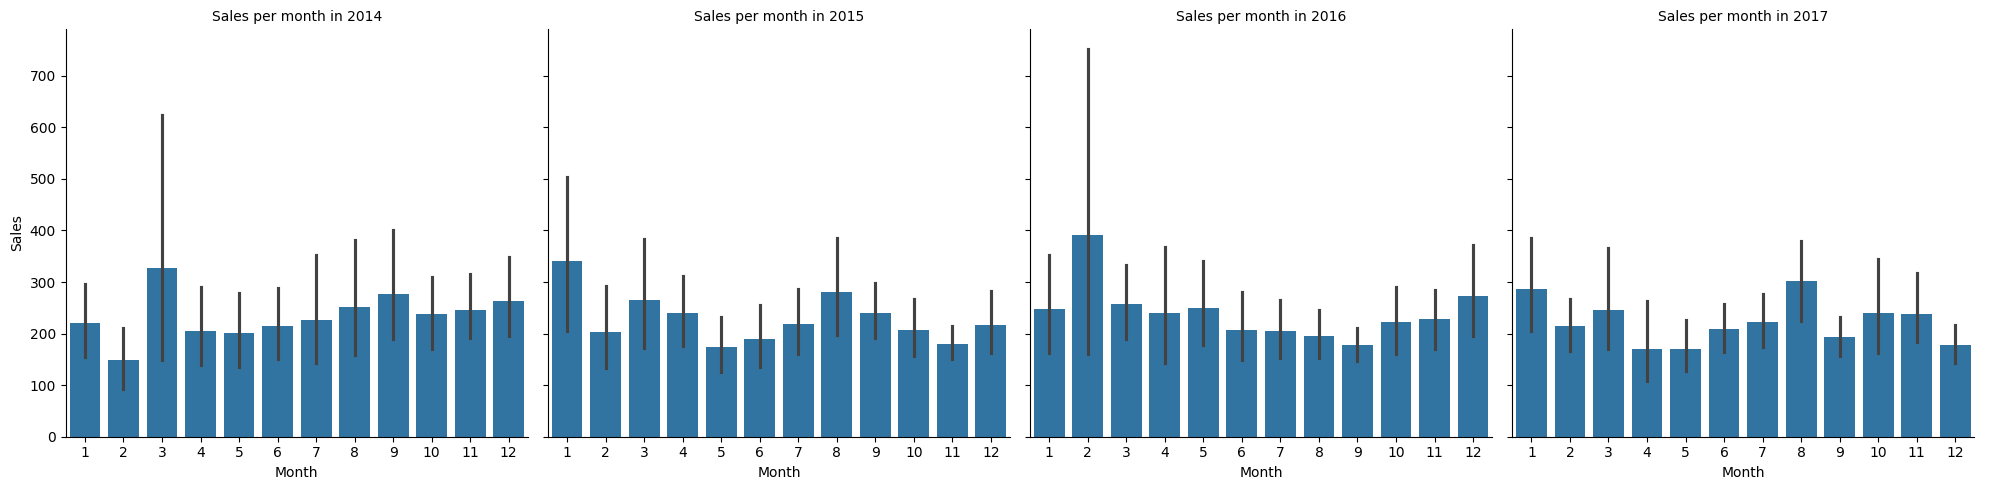

In [55]:
g = sns.catplot(data= data, x="Month", y="Sales", col = "Year", kind="bar")
g.set_titles("Sales per month in {col_name}")
plt.show()


Annual total sales are relatively stable from 2014 through 2017, with no clear upward or downward drift. 2016 shows the highest single‐month spike approx. 400 units in February, but its year-end totals roughly match other years.

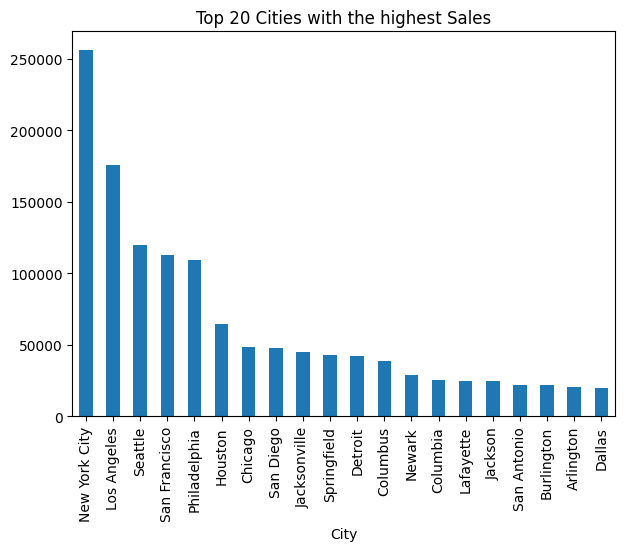

In [56]:
data.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(7, 5))

plt.title("Top 20 Cities with the highest Sales")
plt.show()

This bar chart illustrates the top 20 cities with the highest sales, clearly highlighting significant disparities in performance across locations. New York City leads by a large margin, followed by Los Angeles and Seattle, which also show strong sales volumes. The drop-off from the top 3 to the rest is notable, indicating that a few metropolitan areas are driving the majority of revenue. 

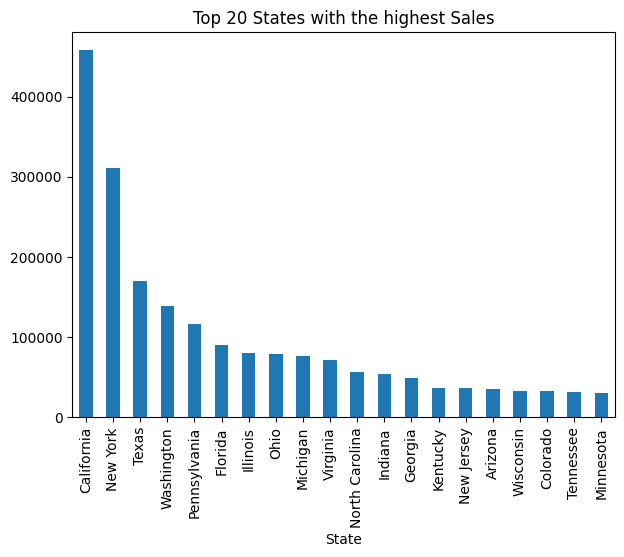

In [14]:
data.groupby("State")["Sales"].sum().sort_values(ascending=False).head(20).plot(kind="bar", figsize=(7, 5))
plt.title("Top 20 States with the highest Sales")
plt.show()

This bar chart shows the top 20 U.S. states with the highest sales. California leads by a significant margin, followed by New York and Texas, indicating these states are key markets. A steep drop in sales is observed after the top three, with the remaining states showing a more gradual decline. This pattern suggests a concentration of sales activity in a few high-performing regions, potentially driven by population density, infrastructure, or business presence.

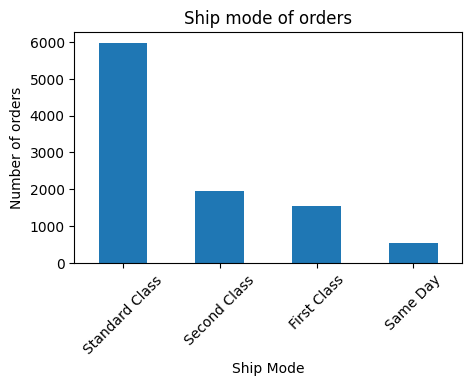

In [15]:
data["Ship_Mode"].value_counts().plot(kind="bar", figsize=(5, 3))
plt.title("Ship mode of orders")
plt.xlabel("Ship Mode")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.show()

This bar chart reveals that the vast majority of orders are shipped via Standard Class, making it by far the most utilized option.

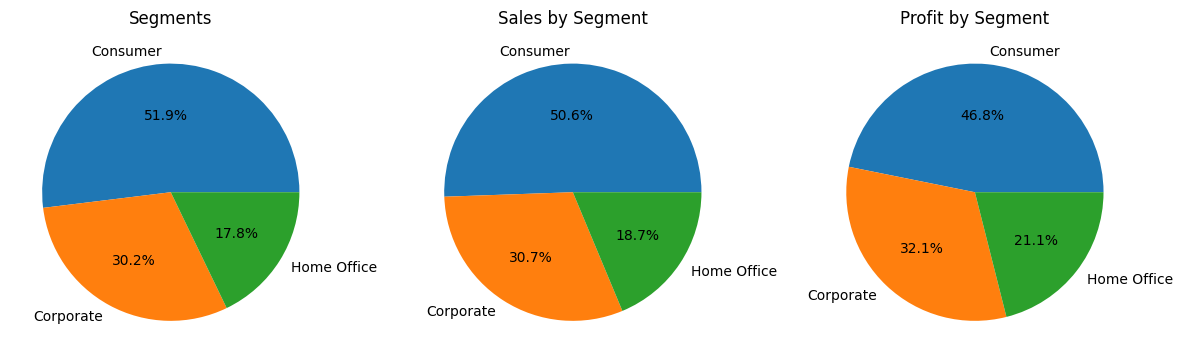

In [16]:
customer_seg = data.groupby("Segment").size()
customer_seg_sales = data.groupby("Segment")["Sales"].sum()
customer_seg_prof = data.groupby("Segment")["Profit"].sum()

labels_seg = customer_seg.index
sizes_seg = customer_seg.values

labels_sales = customer_seg_sales.index
sizes_sales = customer_seg_sales.values

labels_prof = customer_seg_prof.index
sizes_prof = customer_seg_prof.values

plt.figure(figsize = (12, 4))

plt.subplot(1, 3, 1)
plt.pie(sizes_seg, labels=labels_seg, autopct='%1.1f%%')
plt.title("Segments")

plt.subplot(1, 3, 2)
plt.pie(sizes_sales, labels=labels_sales, autopct='%1.1f%%')
plt.title("Sales by Segment")

plt.subplot(1, 3, 3)
plt.pie(sizes_prof, labels= labels_prof, autopct='%1.1f%%')
plt.title("Profit by Segment")

plt.tight_layout()
plt.show()

The three pie charts show that the Consumer segment constitutes just over half of our customer base approx. 52 % and drives roughly the same proportion of sales approx. 51 %, yet its profit share is slightly lower approx. 47 %, suggesting thinner margins. The Corporate segment consistently represents about 30 % of customers and sales but contributes a slightly higher profit share approx. 32 %, indicating healthier profitability. The Home Office segment, while smallest at under 18 % of customers and 19 % of sales, accounts for just over 21 % of profit—its best‐in‐class margin. 

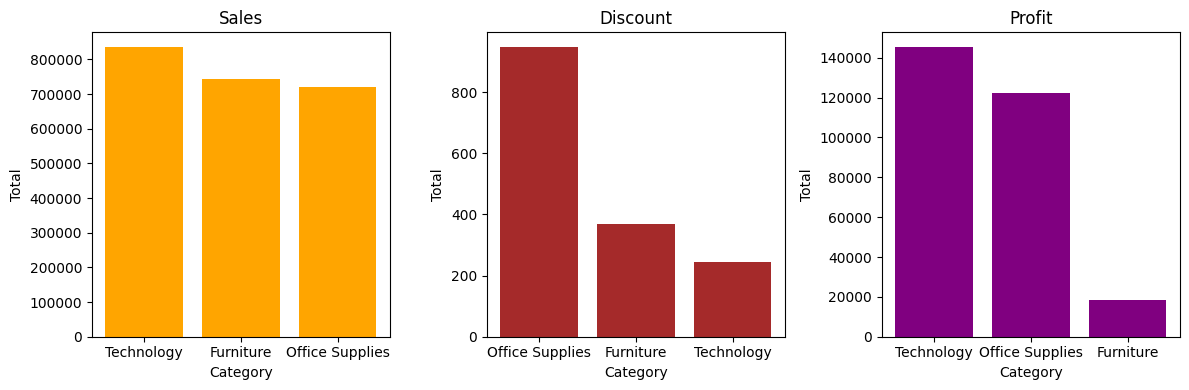

In [17]:
category_sales = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_discount = data.groupby("Category")["Discount"].sum().sort_values(ascending=False)
category_profit = data.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize = (12, 4))

plt.subplot(1, 3, 1)
plt.bar(category_sales.index, category_sales.values, color= "orange")
plt.title("Sales")
plt.xlabel("Category")
plt.ylabel("Total")

plt.subplot(1, 3, 2)
plt.bar(category_discount.index, category_discount.values, color= "brown")
plt.title("Discount")
plt.xlabel("Category")
plt.ylabel("Total")

plt.subplot(1, 3, 3)
plt.bar(category_profit.index, category_profit.values, color= "purple")
plt.title("Profit")
plt.xlabel("Category")
plt.ylabel("Total")

plt.tight_layout()
plt.show()

The bar charts present the analysis of sales, discounts, and profits for three product categories: Technology, Furniture, and Office Supplies. Technology records the highest sales and the largest profits, while Furniture, despite high sales, shows low profits, possibly due to high costs or discounts. Office Supplies receive the highest discounts, but still maintain notable profits, indicating that discounts do not dramatically affect profitability. Overall, Technology is the most profitable category, while Furniture has the lowest performance.

In [18]:
data["Price"] = data["Sales"] / data["Quantity"]

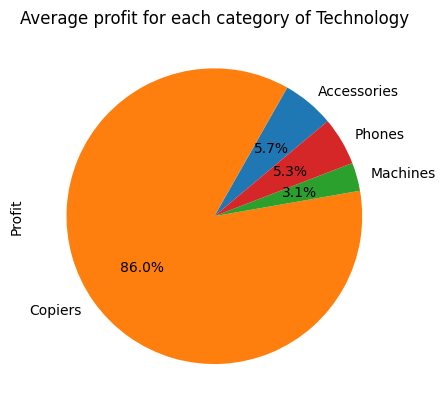

In [19]:
data_tech = data[data["Category"] == "Technology"]
data_tech.groupby("Sub-Category")["Profit"].mean().plot(kind="pie", startangle = 40, autopct='%1.1f%%', title="Average profit for each category of Technology")
plt.show()

The pie chart clearly shows that Copiers dominate the profit within the Technology category, accounting for a massive 86 % of the total. Accessories and Phones contribute modestly, each around 5–6 %, while Machines generate the least profit at just over 3 %. 

C:\Users\jessi\AppData\Local\Temp\ipykernel_10864\2156481381.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)


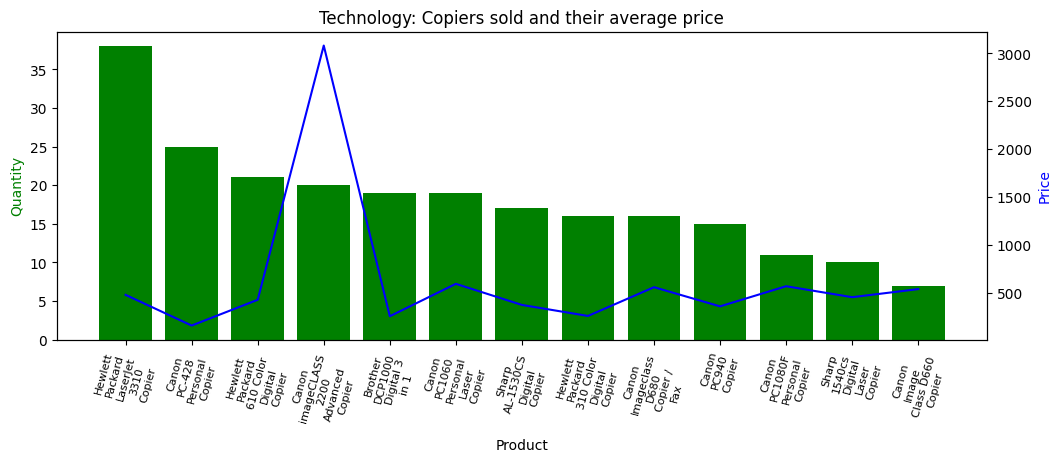

In [20]:
copiers = data[data["Sub-Category"]=="Copiers"]

copiers_sales = copiers.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(20)

products = copiers_sales.index.to_series().apply(lambda x: " ".join(x.split()[:6]))
quantity = copiers_sales.values

prices = data_tech.groupby("Product_Name")["Price"].mean()
prices = prices.loc[products.index]

fig, ax1 = plt.subplots(figsize=(12, 4))

ax2 = ax1.twinx()

ax1.bar(products, quantity, color ="g")
ax2.plot(products, prices,"b-")

plt.title("Technology: Copiers sold and their average price")
ax1.set_xlabel("Product")
ax1.set_ylabel("Quantity", color="g")
ax2.set_ylabel("Price", color="b")

x_labels = products
wrapped_labels = [textwrap.fill(label, width=10) for label in x_labels]
ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)
plt.show()

There is generally a negative correlation between price and sales quantity, as higher-priced copiers tend to sell in lower volumes. However, one product with an exceptionally high price still shows significant sales, indicating either high perceived value or a niche market demand. This suggests that pricing strategy should consider both demand elasticity and product differentiation.

C:\Users\jessi\AppData\Local\Temp\ipykernel_10864\2251663137.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)


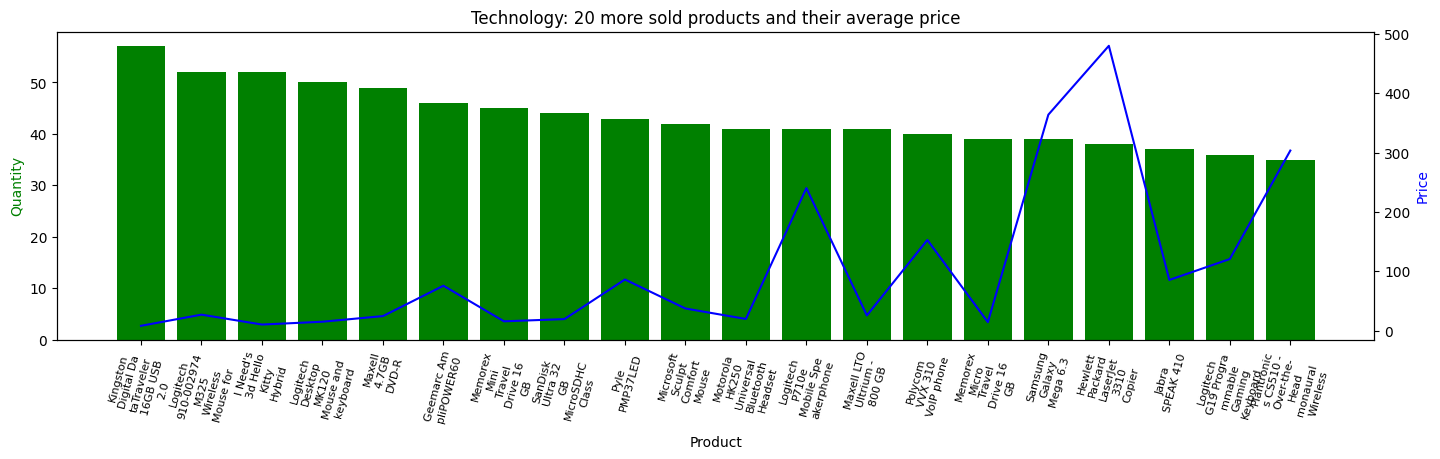

In [21]:
quantity_ordered_tech = data_tech.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(20)

products = quantity_ordered_tech.index.to_series().apply(lambda x: " ".join(x.split()[:6]))
quantity = quantity_ordered_tech.values

prices = data_tech.groupby("Product_Name")["Price"].mean()
prices = prices.loc[products.index]

fig, ax1 = plt.subplots(figsize=(17, 4))

ax2 = ax1.twinx()

ax1.bar(products, quantity, color ="g")
ax2.plot(products, prices,"b-")

plt.title("Technology: 20 more sold products and their average price")
ax1.set_xlabel("Product")
ax1.set_ylabel("Quantity", color="g")
ax2.set_ylabel("Price", color="b")

x_labels = products
wrapped_labels = [textwrap.fill(label, width=10) for label in x_labels]
ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)
plt.show()

The data shows that the products which are sold most are low-cost items. There is a negative correlation between price and sales quantity, as higher-priced products tend to sell in lower quantities. 

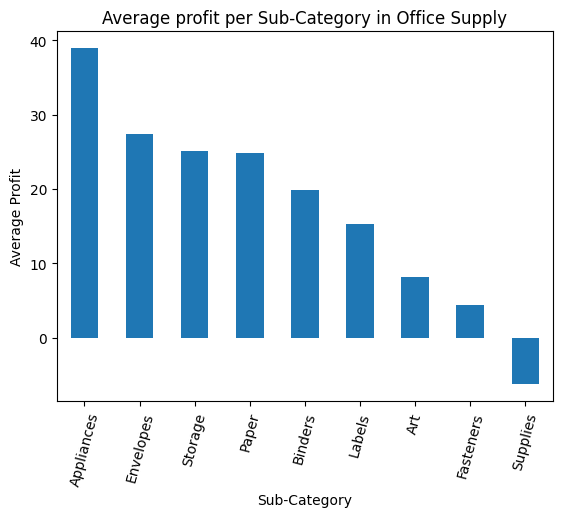

In [22]:
data_office_sup = data[data["Category"] == "Office Supplies"]
data_office_sup.groupby("Sub-Category")["Profit"].mean().sort_values(ascending=False).plot(kind="bar")

plt.title("Average profit per Sub-Category in Office Supply")
plt.xlabel("Sub-Category")
plt.ylabel('Average Profit')
plt.xticks(rotation=75)
plt.show()

The chart shows that within the Office Supply category, Appliances generate the highest average profit, followed by Envelopes, Storage, and Paper. On the other hand, categories like Fasteners and especially Supplies perform poorly, with Supplies even showing a negative average profit.

C:\Users\jessi\AppData\Local\Temp\ipykernel_10864\443976794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  supplies["Profit"] = supplies["Profit"].abs()


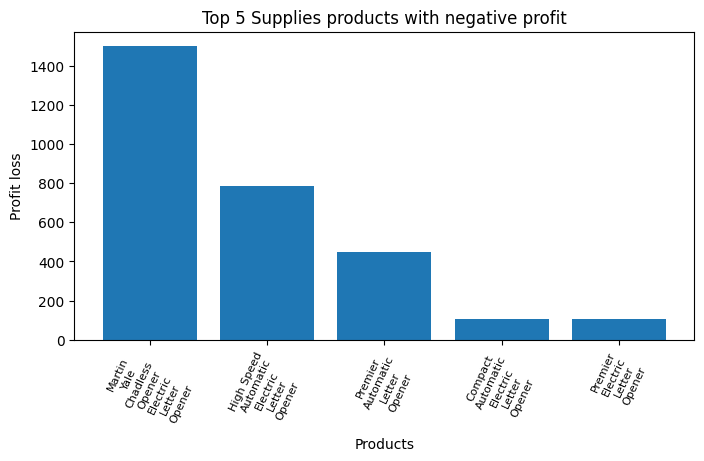

In [23]:
supplies = data[(data["Profit"]<0) & (data["Sub-Category"]=="Supplies")]
# We take the absolute value
supplies["Profit"] = supplies["Profit"].abs()

supplies_neg_profit_product = supplies.groupby("Product_Name")["Profit"].sum().sort_values(ascending=False).head(5)

products_neg_prof = supplies_neg_profit_product.index
neg_profit = supplies_neg_profit_product.values

plt.figure(figsize=(8, 4))
plt.bar(products_neg_prof, neg_profit)
plt.title("Top 5 Supplies products with negative profit")
plt.xlabel("Products")
plt.ylabel("Profit loss")
x_labels = products_neg_prof
wrapped_labels = [textwrap.fill(label, width=10) for label in x_labels]
plt.xticks(ticks=range(len(x_labels)), labels=wrapped_labels, rotation=65, fontsize = 8)

plt.show()


This bar chart highlights the top 5 supplies products with the highest profit loss. The "Martin Chairs Electric Letter Opener" shows a significantly higher negative profit compared to the others, followed by the "High Speed Automatic Electric Letter Opener" and "Premier Automatic Electric Letter Opener." These products may need cost re-evaluation, pricing adjustments, or even discontinuation if the trend continues. The repeated presence of electric letter openers suggests a broader issue within this product category.

C:\Users\jessi\AppData\Local\Temp\ipykernel_10864\1958985879.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)


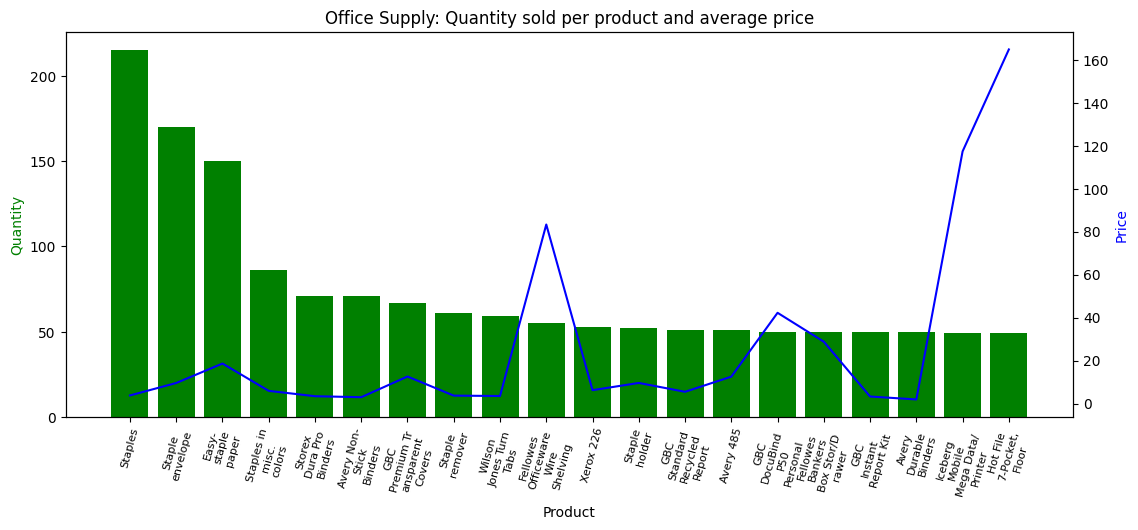

In [57]:
quantity_ordered_sup = data_office_sup.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(20)
products_sup = quantity_ordered_sup.index.to_series().apply(lambda x: " ".join(x.split()[:4]))
quantity_sup = quantity_ordered_sup.values

prices_sup = data_office_sup.groupby("Product_Name")["Price"].mean()
prices_sup = prices_sup.loc[products_sup.index]

fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()

ax1.bar(products_sup, quantity_sup, color ="g")
ax2.plot(products_sup, prices_sup,"b-")

plt.title("Office Supply: Quantity sold per product and average price")
ax1.set_xlabel("Product")
ax1.set_ylabel("Quantity", color="g")
ax2.set_ylabel("Price", color="b")

x_labels = products_sup
wrapped_labels = [textwrap.fill(label, width=10) for label in x_labels]
ax1.set_xticklabels(labels=wrapped_labels, rotation=75, fontsize = 8)
plt.show()

This chart shows the quantity sold and average price for Office Supply products. Products like Staples, Staple envelope, and Easy paper have high sales volumes but relatively low prices, suggesting they are everyday low-cost essentials. On the other hand, items such as Hot File 7-Pocket Floor have the highest average prices but low sales quantities, indicating they are niche or premium products. 

#### **List of items which are sold together**

In [58]:
df = data.copy()  

df["Product_Name"] = df["Product_Name"].str.replace(",", "-")

df_filtered = df[df["Order_ID"].duplicated(keep=False)]

df_filtered["Grouped"] = df_filtered.groupby("Order_ID")["Product_Name"].transform(lambda x:",".join(x))

df_filtered = df_filtered[["Order_ID","Grouped"]].drop_duplicates()


C:\Users\jessi\AppData\Local\Temp\ipykernel_10864\480324818.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Grouped"] = df_filtered.groupby("Order_ID")["Product_Name"].transform(lambda x:",".join(x))


In [59]:
from itertools import combinations
from collections import Counter

count = Counter()

for row in df_filtered["Grouped"]:
    row_list = row.split(",")
    count.update(Counter(combinations(row_list, 2)))

for key, value in count.most_common(20):
    print(key,value)

('Anker 36W 4-Port USB Wall Charger Travel Power Adapter for iPhone 5s 5c 5', 'Staples') 2
('Staples', 'Square Credit Card Reader- 4 1/2" x 4 1/2" x 1"- White') 2
('Sabrent 4-Port USB 2.0 Hub', 'Xerox 1881') 2
('Xerox 1881', 'GBC DocuBind P400 Electric Binding System') 2
('GBC ProClick 150 Presentation Binding System', 'Imation\xa0Secure+ Hardware Encrypted USB 2.0\xa0Flash Drive; 16GB') 2
('Imation\xa0Secure+ Hardware Encrypted USB 2.0\xa0Flash Drive; 16GB', 'Woodgrain Magazine Files by Perma') 2
('Advantus Rolling Storage Box', 'Great White Multi-Use Recycled Paper (20Lb. and 84 Bright)') 2
('Xerox 225', 'Xerox 1894') 2
('Insertable Tab Post Binder Dividers', 'GBC VeloBinder Manual Binding System') 2
('DAX Value U-Channel Document Frames- Easel Back', 'Recycled Easel Ring Binders') 2
('Cisco SPA508G', 'Global Commerce Series High-Back Swivel/Tilt Chairs') 2
('Acco Hanging Data Binders', 'Newell 315') 2
('GBC Plastic Binding Combs', 'Hon Valutask Swivel Chairs') 2
('Xerox 192', 'X-Rac

###  **KMeans Clustering**

In [60]:
aggragated_df = data.groupby("Customer_ID", as_index = False) \
                .agg(
                    Monetary_Value = ("Sales", "sum"),
                    Frequency = ("Order_ID", "nunique"),
                    Last_Order_Date = ("Order_Date", "max")
                )
aggragated_df.head(5)

,Customer_ID,Monetary_Value,Frequency,Last_Order_Date
0,AA-10315,5563.560,5,2017-06-29
1,AA-10375,1056.390,9,2017-11-12
2,AA-10480,1790.512,4,2017-04-15
3,AA-10645,5086.935,6,2017-05-11
4,AB-10015,886.156,3,2016-10-11


In [61]:
max_order_date = aggragated_df["Last_Order_Date"].max()

aggragated_df["Recency"] = (max_order_date - aggragated_df["Last_Order_Date"]).dt.days

aggragated_df.head(5)

,Customer_ID,Monetary_Value,Frequency,Last_Order_Date,Recency
0,AA-10315,5563.560,5,2017-06-29,184
1,AA-10375,1056.390,9,2017-11-12,48
2,AA-10480,1790.512,4,2017-04-15,259
3,AA-10645,5086.935,6,2017-05-11,233
4,AB-10015,886.156,3,2016-10-11,445


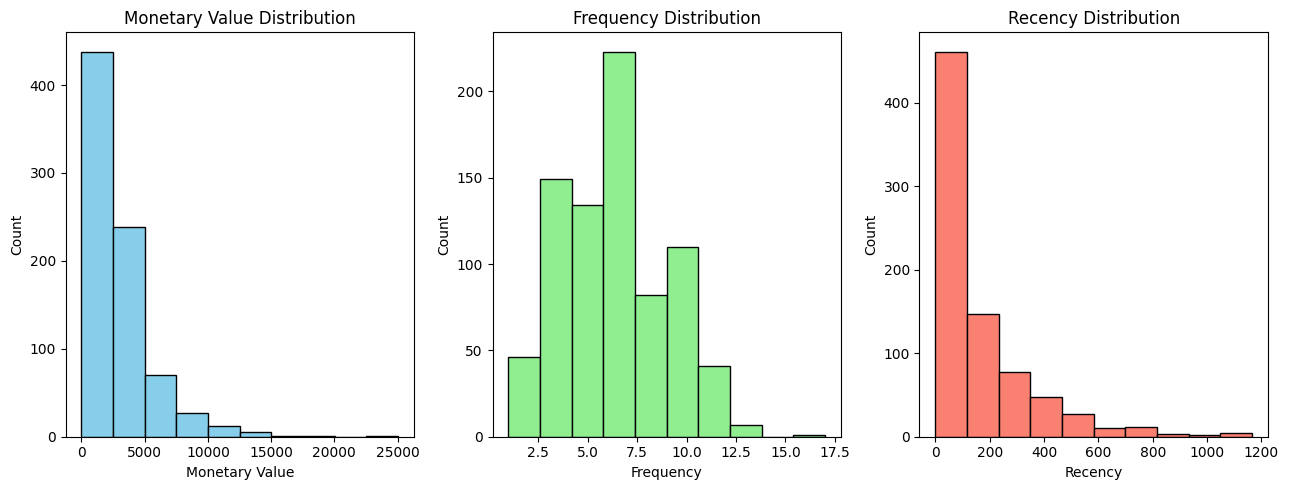

In [62]:
plt.figure(figsize = (13, 5))

plt.subplot(1, 3, 1)
plt.hist(aggragated_df["Monetary_Value"], bins= 10, color= "skyblue", edgecolor = "black")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
plt.hist(aggragated_df["Frequency"], bins= 10, color= "lightgreen", edgecolor = "black")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
plt.hist(aggragated_df["Recency"], bins= 10, color= "salmon", edgecolor = "black")
plt.title("Recency Distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

The Monetary Value Distribution shows that most customers have low spending, with a steep drop-off as monetary value increases, suggesting a small number of high-value customers. The Frequency Distribution indicates that most customers purchase between 3 to 10 times, pointing to moderate repeat buying activity, with fewer very frequent buyers. The Recency Distribution reveals that the majority of customers have purchased recently, while fewer haven't bought for a long time, highlighting a generally engaged customer base.

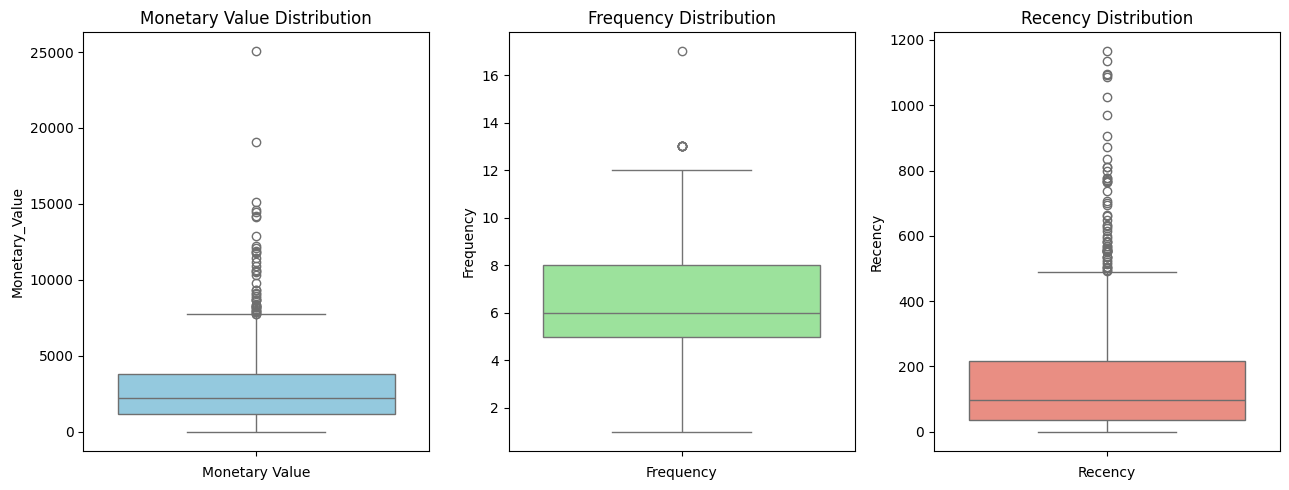

In [63]:
plt.figure(figsize = (13, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data= aggragated_df["Monetary_Value"],color= "skyblue")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")

plt.subplot(1, 3, 2)
sns.boxplot(data=aggragated_df["Frequency"], color= "lightgreen")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(data=aggragated_df["Recency"], color= "salmon")
plt.title("Recency Distribution")
plt.xlabel("Recency")

plt.tight_layout()
plt.show()

The boxplots provide a clear visualization of value distribution and potential outliers across the RFM metrics. The Monetary Value plot shows a high concentration of customers generating low to moderate revenue, with a small but significant group of high-spending outliers. Τhese may represent key strategic accounts worth closer attention. The Frequency distribution indicates that most customers place orders fairly consistently. Lastly, the Recency plot reveals that most customers have engaged recently, yet a tail of outliers indicates a subset of inactive or lost customers that may require reactivation strategies or churn analysis.

In [31]:
M_Q1 = aggragated_df["Monetary_Value"].quantile(0.25)
M_Q3 = aggragated_df["Monetary_Value"].quantile(0.75)

M_IQR = M_Q3 - M_Q1

monetary_outliers_df = aggragated_df[(aggragated_df["Monetary_Value"] > (M_Q3 + 1.5 * M_IQR)) | (aggragated_df["Monetary_Value"] < (M_Q1 - 1.5 * M_IQR))].copy()

monetary_outliers_df.describe()


,Monetary_Value,Frequency,Last_Order_Date,Recency
count,43.000000,43.000000,43,43.000000
mean,10704.986972,8.023256,2017-08-03 06:08:22.325581312,148.744186
min,7754.976000,3.000000,2015-09-17 00:00:00,2.000000
25%,8302.592000,6.000000,2017-07-11 12:00:00,36.500000
50%,9351.212000,8.000000,2017-11-06 00:00:00,54.000000
75%,11855.935500,10.500000,2017-11-23 12:00:00,171.500000
max,25043.050000,13.000000,2017-12-28 00:00:00,835.000000
std,3384.488747,2.824117,NaN,187.039987


In [32]:
M_Q1 = aggragated_df["Frequency"].quantile(0.25)
M_Q3 = aggragated_df["Frequency"].quantile(0.75)

M_IQR = M_Q3 - M_Q1

frequency_outliers_df = aggragated_df[(aggragated_df["Frequency"] > (M_Q3 + 1.5 * M_IQR)) | (aggragated_df["Frequency"] < (M_Q1 - 1.5 * M_IQR))].copy()

frequency_outliers_df.describe()

,Monetary_Value,Frequency,Last_Order_Date,Recency
count,8.000000,8.000000,8,8.000000
mean,4465.589037,13.500000,2017-10-21 12:00:00,69.500000
min,2846.705000,13.000000,2017-07-31 00:00:00,12.000000
25%,3056.386000,13.000000,2017-09-18 06:00:00,33.250000
50%,3280.847250,13.000000,2017-11-01 00:00:00,59.000000
75%,5798.749350,13.000000,2017-11-26 18:00:00,102.750000
max,8025.707000,17.000000,2017-12-18 00:00:00,152.000000
std,2020.623096,1.414214,NaN,48.308532


In [33]:
non_outliers_df = aggragated_df[(~aggragated_df.index.isin(monetary_outliers_df.index)) & (~aggragated_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,Monetary_Value,Frequency,Last_Order_Date,Recency
count,743.000000,743.000000,743,743.000000
mean,2434.976333,6.149394,2017-07-17 21:36:34.885598976,165.099596
min,4.833000,1.000000,2014-10-22 00:00:00,0.000000
25%,1069.358250,4.000000,2017-05-22 00:00:00,37.000000
50%,2163.300000,6.000000,2017-09-24 00:00:00,97.000000
75%,3321.021000,8.000000,2017-11-23 00:00:00,222.000000
max,7721.714000,12.000000,2017-12-30 00:00:00,1165.000000
std,1717.791723,2.404628,NaN,191.410619


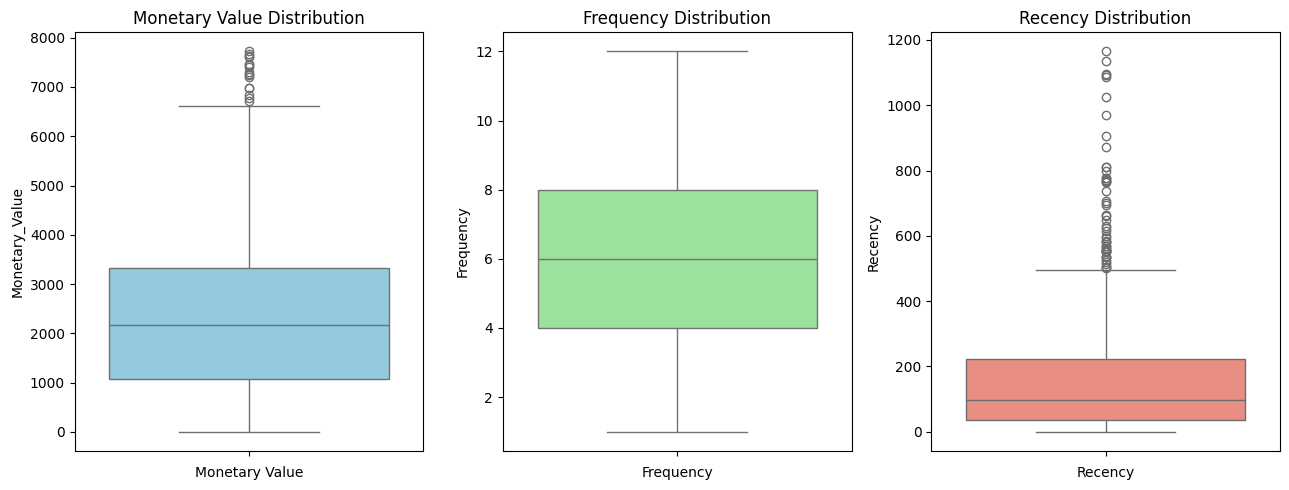

In [34]:
plt.figure(figsize = (13, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data= non_outliers_df["Monetary_Value"],color= "skyblue")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df["Frequency"], color= "lightgreen")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df["Recency"], color= "salmon")
plt.title("Recency Distribution")
plt.xlabel("Recency")

plt.tight_layout()
plt.show()

The Monetary Value distribution of non-outliers shows a relatively wide interquartile range, indicating diverse spending habits, with several high-spending customers standing out as outliers above approximately $6,700. Frequency is more tightly clustered around the median of 6, suggesting consistent purchasing behavior among the majority of customers, though a few show higher repeat engagement. The Recency plot reveals a strong right skew, with most customers having made recent purchases, while a notable number of outliers represent customers who haven’t engaged in a long time, possibly signaling churn. 

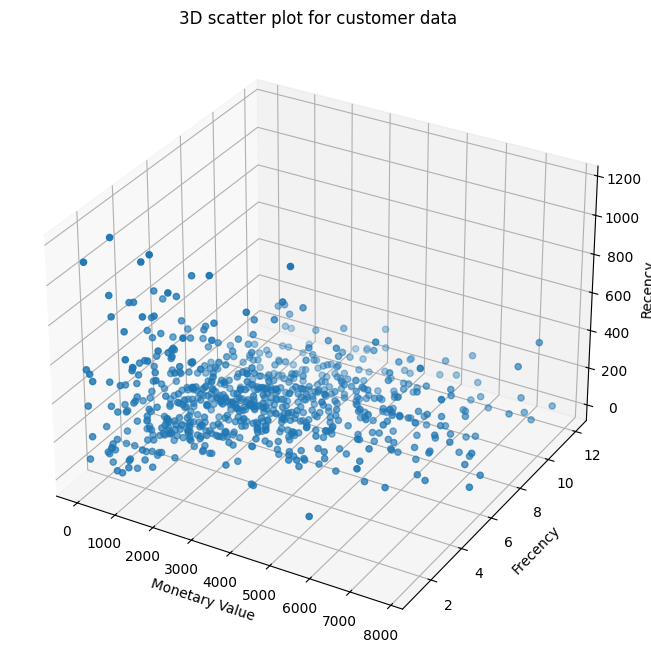

In [35]:
fig = plt.figure(figsize=(10,8))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["Monetary_Value"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frecency")
ax.set_zlabel("Recency")

ax.set_title("3D scatter plot for customer data")

plt.show()

In [36]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[["Monetary_Value", "Frequency", "Recency"]])

scaled_data_df = pd.DataFrame(scaled_data, index=non_outliers_df.index, columns=("Monetary_Value", "Frequency", "Recency"))

scaled_data_df

,Monetary_Value,Frequency,Recency
0,1.822509,-0.478315,0.098809
1,-0.803075,1.186265,-0.612184
2,-0.375423,-0.894460,0.490901
3,1.544858,-0.062170,0.354976
4,-0.902242,-1.310605,1.463288
...,...,...,...
787,2.170016,2.018555,-0.606956
788,-0.035138,2.018555,-0.638323
789,1.758891,-0.478315,-0.842211
790,2.496434,0.770120,-0.816071


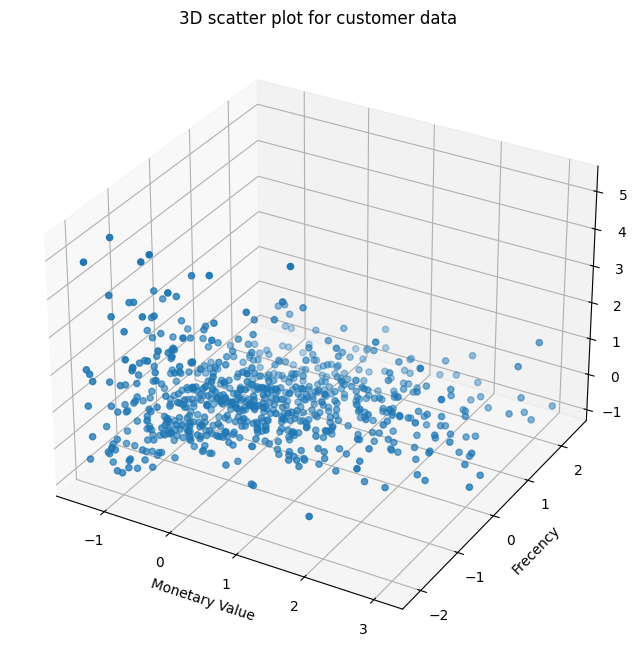

In [37]:
fig = plt.figure(figsize=(10,8))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["Monetary_Value"], scaled_data_df["Frequency"], scaled_data_df["Recency"])

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frecency")
ax.set_zlabel("Recency")

ax.set_title("3D scatter plot for customer data")

plt.show()

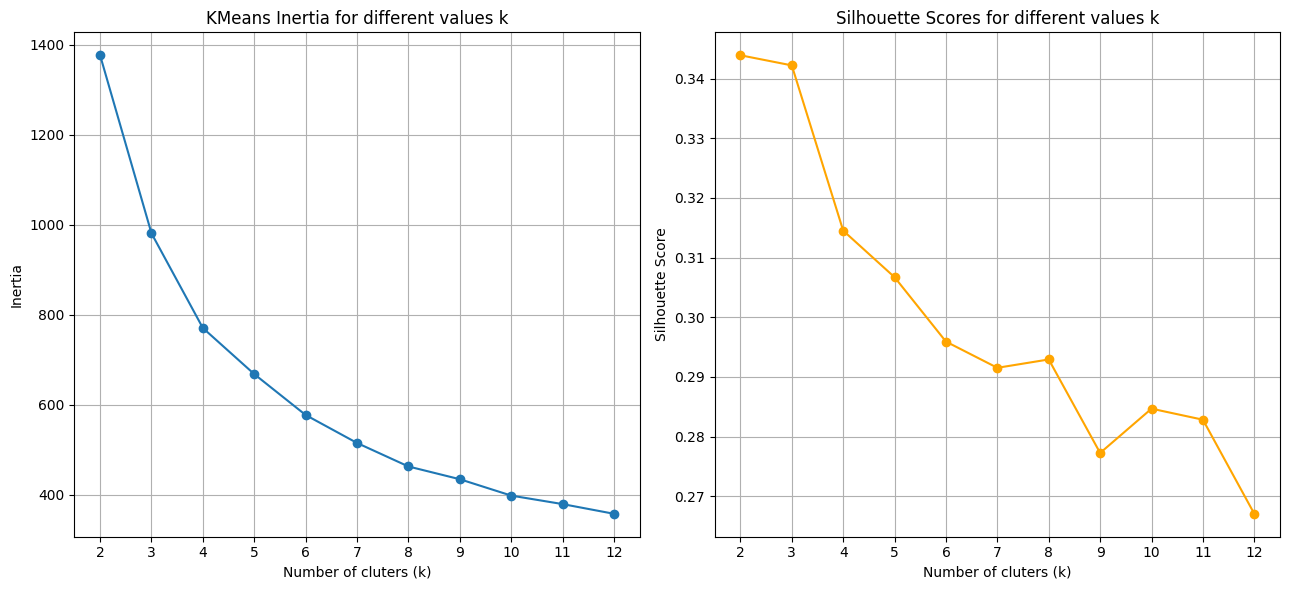

In [38]:
max_k = 12

inertia = []
silhouette_scores = []

k_values = range(2, max_k +1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state = 42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(scaled_data_df)
    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(13,6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker="o")
plt.title("KMeans Inertia for different values k")
plt.xlabel("Number of cluters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker="o", color="orange")
plt.title("Silhouette Scores for different values k")
plt.xlabel("Number of cluters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [64]:
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=1000)
cluster_labels= kmeans.fit_predict(scaled_data_df)

non_outliers_df["Cluster"] = cluster_labels

non_outliers_df


,Customer_ID,Monetary_Value,Frequency,Last_Order_Date,Recency,Cluster
0,AA-10315,5563.560,5,2017-06-29,184,0
1,AA-10375,1056.390,9,2017-11-12,48,2
2,AA-10480,1790.512,4,2017-04-15,259,2
3,AA-10645,5086.935,6,2017-05-11,233,0
4,AB-10015,886.156,3,2016-10-11,445,1
...,...,...,...,...,...,...
787,WB-21850,6160.102,11,2017-11-11,49,0
788,XP-21865,2374.658,11,2017-11-17,43,0
789,YC-21895,5454.350,5,2017-12-26,4,0
790,YS-21880,6720.444,8,2017-12-21,9,0


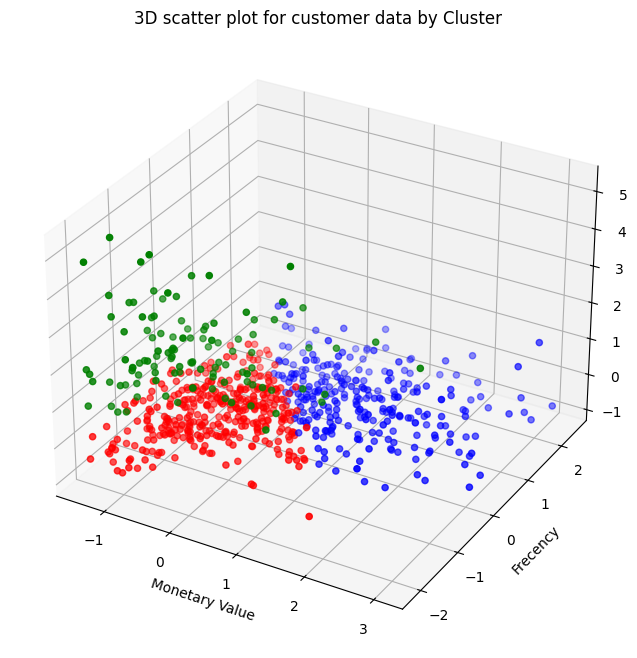

In [65]:
cluster_colors = {0: "blue", 1:"green", 2: "red"}
colors = non_outliers_df["Cluster"].map(cluster_colors)

fig = plt.figure(figsize=(10,8))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_data_df["Monetary_Value"], scaled_data_df["Frequency"], scaled_data_df["Recency"], c=colors, marker="o")

ax.set_xlabel("Monetary Value")
ax.set_ylabel("Frecency")
ax.set_zlabel("Recency")

ax.set_title("3D scatter plot for customer data by Cluster")

plt.show()

After applying StandardScaler, each variable Monetary Value, Frequency and Recency has been normalized to mean zero and unit variance, which helps visualize cluster separations more distinctly. The red, green, and blue clusters are well-formed, indicating that customers group naturally into segments with differing behavioral characteristics.  The blue cluster, positioned higher on standardized Monetary Value and Frequency but lower on Recency, likely represents loyal, high-value customers who purchase frequently and recently. The red cluster consists of customers who don’t spend much, low Monetary Value, are spread across almost the full range of Frequency with a concentration around the middle, and have low Recency, meaning they’ve purchased recently. This suggests they are fairly active but low-value customers. The green cluster, which appears higher on standardized Recency and lower on Frequency and Monetary, likely captures at-risk or lapsed customers who haven't purchased recently and show low engagement and spending.

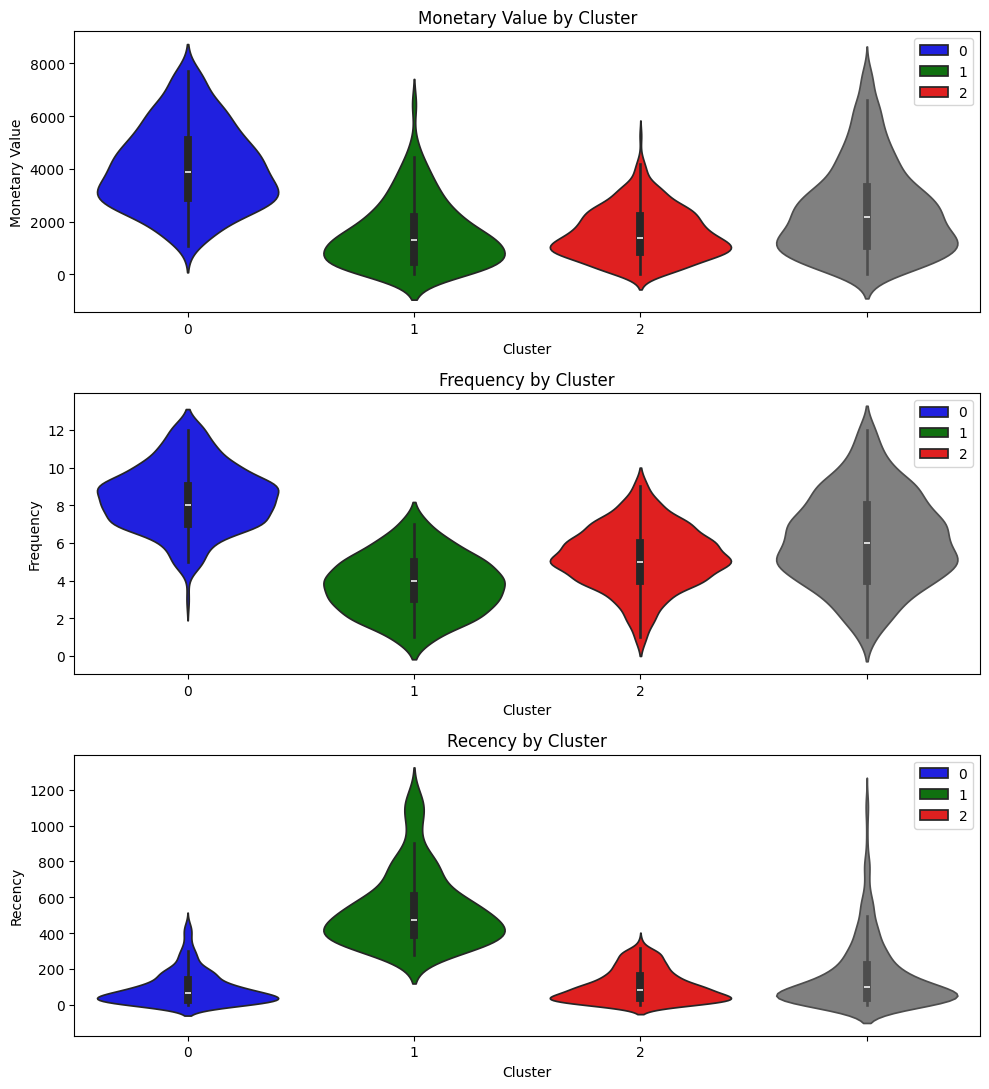

In [43]:
plt.figure(figsize=(10,11))

plt.subplot(3,1,1)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["Monetary_Value"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["Monetary_Value"], color="grey")
plt.title("Monetary Value by Cluster")
plt.ylabel("Monetary Value")

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["Frequency"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["Frequency"], color="grey")
plt.title("Frequency by Cluster")
plt.ylabel("Frequency")

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["Recency"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["Recency"], color="grey")
plt.title("Recency by Cluster")
plt.ylabel("Recency")

plt.tight_layout()
plt.show()

These violin plots provide a comprehensive view of the distribution of Monetary Value, Frequency, and Recency across the identified customer clusters. Cluster 0 (blue) represents high-value customers with consistently high spending and frequent purchases, coupled with low recency, they are recent, loyal, and profitable clients. Cluster 1 (green) includes customers with low spending and frequency, and high recency, indicating they are inactive or at-risk customers who haven't transacted in a while. Cluster 2 (red) is made up of relatively active customers with low to moderate spending, moderate frequency, and low recency, meaning they’ve interacted recently but do not contribute significantly in value